<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week9/day3-4/HeartDisease_LogisticRegression_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 Mini-Project: Predicting Heart Disease Using Logistic Regression

## 👩‍🏫 What You'll Learn
- How to handle real-world healthcare data
- Preprocessing: missing values, categorical variables, and feature scaling
- Training a Logistic Regression model to predict heart disease
- Evaluating performance with accuracy, precision, recall, F1 score, and a confusion matrix

## 💼 Tools & Libraries
| Tool | Purpose |
|---|---|
| `pandas` | Data loading & manipulation |
| `scikit-learn` | Preprocessing, modelling, evaluation |
| `matplotlib` / `seaborn` | Visualisation |


## 0. Setup & Imports

In [11]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ Libraries loaded")


✅ Libraries loaded


## 1. Load the Dataset

Download the Heart Disease UCI dataset and extract it.
The ZIP is fetched directly from the bootcamp GitHub repository.


In [12]:
import urllib.request

URL = (
    "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/"
    "Week%205/Day%205%20-%20Mini%20Project/UCI%20Heart%20Disease%20Data.zip"
)
ZIP_PATH = "heart_disease.zip"
OUT_DIR  = "heart_data"

if not os.path.exists(ZIP_PATH):
    print("Downloading dataset...")
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print("Download complete.")

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)
    print("Files extracted:", z.namelist())


Files extracted: ['heart_disease_uci.csv']


In [13]:
# Locate the CSV file
csv_files = []
for root, dirs, files in os.walk(OUT_DIR):
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("CSV files found:", csv_files)

df = pd.read_csv(csv_files[0])
print(f"\nDataset shape: {df.shape}")
df.head()


CSV files found: ['heart_data/heart_disease_uci.csv']

Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [14]:
print(df.head(20))

    id  age     sex    dataset               cp  trestbps   chol    fbs  \
0    1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1    2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2    3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3    4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4    5   41  Female  Cleveland  atypical angina     130.0  204.0  False   
5    6   56    Male  Cleveland  atypical angina     120.0  236.0  False   
6    7   62  Female  Cleveland     asymptomatic     140.0  268.0  False   
7    8   57  Female  Cleveland     asymptomatic     120.0  354.0  False   
8    9   63    Male  Cleveland     asymptomatic     130.0  254.0  False   
9   10   53    Male  Cleveland     asymptomatic     140.0  203.0   True   
10  11   57    Male  Cleveland     asymptomatic     140.0  192.0  False   
11  12   56  Female  Cleveland  atypical angina     140.0  294.0  False   
12  13   56    Male  Clev

## 2. Exploratory Data Analysis (EDA)

Before any modelling, we need to understand our data: its structure, distributions,
missing values, and class balance.


In [15]:
# ── Basic info ──
print("=== Data Types & Non-Null Counts ===")
print(df.info())


=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None


In [16]:
# ── Summary statistics ──
print("=== Descriptive Statistics ===")
df.describe().T


=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


In [17]:
# ── Missing values ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0]

if missing_df.empty:
    print("✅ No missing values found.")
else:
    print("⚠️  Missing values detected:")
    print(missing_df)


⚠️  Missing values detected:
          Missing Count  Missing %
trestbps             59       6.41
chol                 30       3.26
fbs                  90       9.78
restecg               2       0.22
thalch               55       5.98
exang                55       5.98
oldpeak              62       6.74
slope               309      33.59
ca                  611      66.41
thal                486      52.83


In [18]:
# ── Target column: 'heart disease' ──
# Values > 1 indicate presence of disease; recode to binary (0 = No, 1 = Yes)
print("Original target value counts:")
print(df["num"].value_counts())

df["target"] = (df["num"] > 0).astype(int)

print("\nBinary target value counts:")
print(df["target"].value_counts())


Original target value counts:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary target value counts:
target
1    509
0    411
Name: count, dtype: int64


In [19]:
X = df.drop(columns=["id", "num", "target", "dataset"])

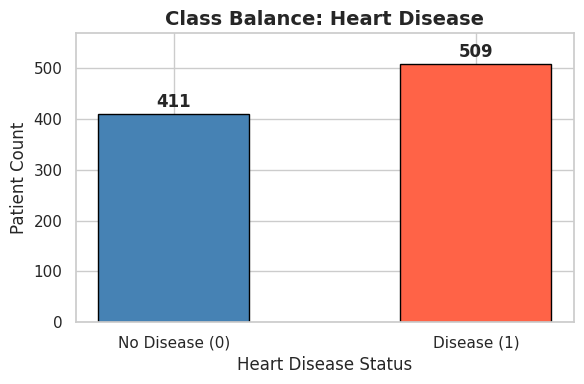

Class ratio (Disease / No Disease): 1.24
→ Reasonably balanced — no special resampling needed


In [20]:
# ── Class balance bar chart ───────────────────────────────────────────────────
# Visualise how evenly split our target classes are
# A severe imbalance would require special handling (e.g. SMOTE, class weights)

fig, ax = plt.subplots(figsize=(6, 4))

counts = df["target"].value_counts().sort_index()
bars = ax.bar(
    ["No Disease (0)", "Disease (1)"],
    counts.values,
    color=["steelblue", "tomato"],
    edgecolor="black",
    width=0.5,
)

# Annotate each bar with its count
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=12, fontweight="bold",
    )

ax.set_title("Class Balance: Heart Disease", fontsize=14, fontweight="bold")
ax.set_ylabel("Patient Count")
ax.set_xlabel("Heart Disease Status")
ax.set_ylim(0, counts.max() + 60)

plt.tight_layout()
plt.show()

print(f"Class ratio (Disease / No Disease): {counts[1] / counts[0]:.2f}")
print("→ Reasonably balanced — no special resampling needed")

## 2. Exploratory Data Analysis (EDA)

Before building any model, we explore the dataset to understand:
- The distribution of individual features
- Relationships between features and the target
- Missing values that need to be handled

Numeric features to plot (6): ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


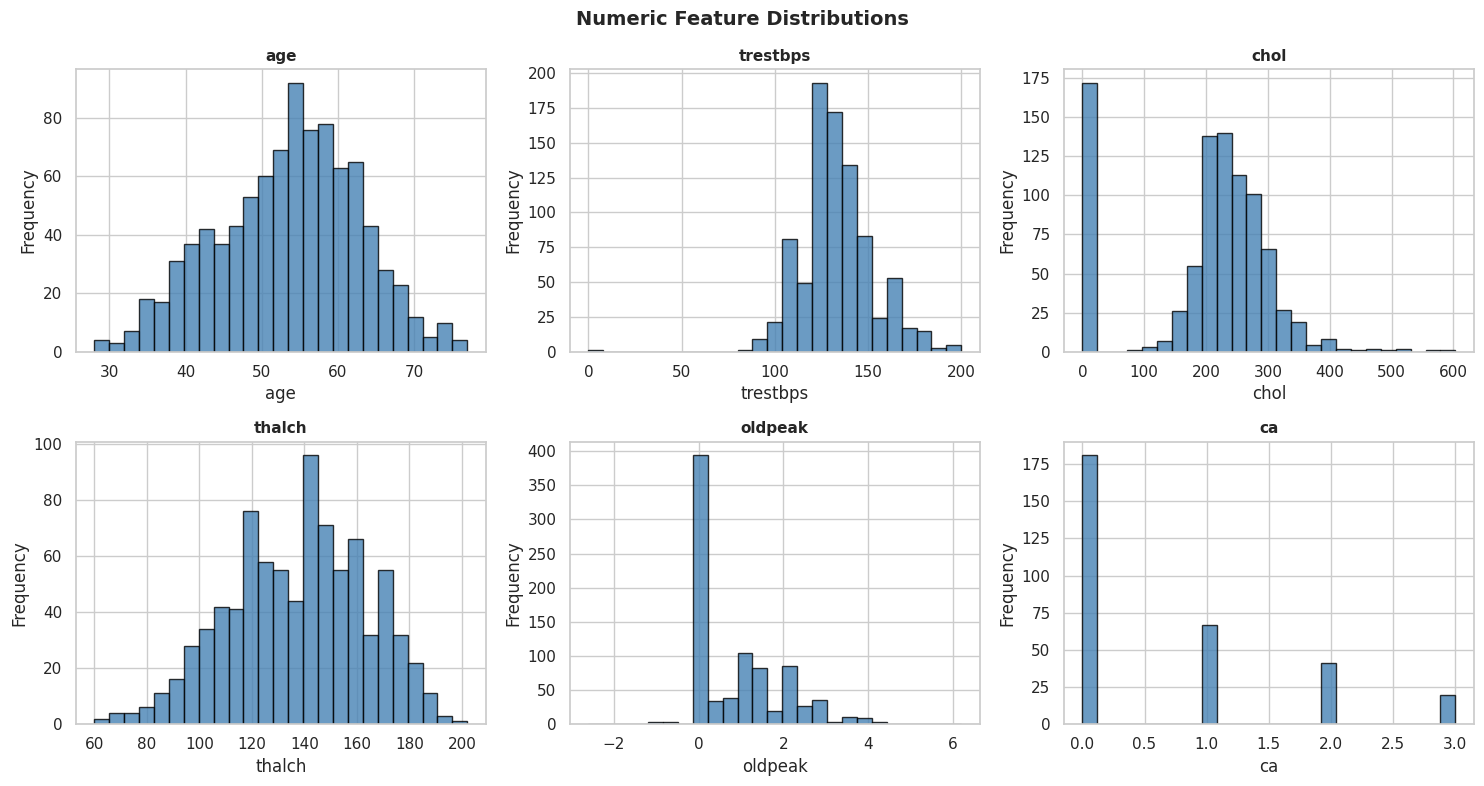

In [21]:
# ── Numeric feature distributions ────────────────────────────────────────────
# Histograms help us spot skew, outliers, and unusual distributions
# We exclude id, num, and target since these aren't clinical features

numeric_cols = df.select_dtypes(include="number").drop(
    columns=["id", "num", "target"], errors="ignore"
).columns.tolist()

print(f"Numeric features to plot ({len(numeric_cols)}): {numeric_cols}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=25, color="steelblue", edgecolor="black", alpha=0.8)
    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused subplots if fewer than 6 numeric columns
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Missing Values
Several columns have missing data that must be handled before training.
We will drop columns with >50% missing values and impute the rest.

In [22]:
# ── Missing value analysis ────────────────────────────────────────────────────
# We need to understand the extent of missing data before deciding how to handle it

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

# Only show columns that actually have missing values
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print("Columns with missing values:")
print(missing_df.to_string())
print(f"\nTotal columns affected: {len(missing_df)}")

Columns with missing values:
          Missing Count  Missing %
ca                  611      66.41
thal                486      52.83
slope               309      33.59
fbs                  90       9.78
oldpeak              62       6.74
trestbps             59       6.41
exang                55       5.98
thalch               55       5.98
chol                 30       3.26
restecg               2       0.22

Total columns affected: 10


### Handling Missing Values

Based on the missing value analysis, we apply the following strategy:

| Column | Missing % | Action |
|---|---|---|
| `ca` | 66.41% | Drop — too sparse to impute reliably |
| `thal` | 52.83% | Drop — too sparse to impute reliably |
| `slope` | 33.59% | Impute with mode (most frequent value) |
| `fbs` | 9.78% | Impute with mode |
| `oldpeak` | 6.74% | Impute with median |
| `trestbps` | 6.41% | Impute with median |
| `exang` | 5.98% | Impute with mode |
| `thalch` | 5.98% | Impute with median |
| `chol` | 3.26% | Impute with median |
| `restecg` | 0.22% | Impute with mode |

**Rule of thumb:** Columns with >50% missing are dropped. Numeric columns are filled with the **median** (robust to outliers); categorical columns are filled with the **mode** (most frequent category).

In [23]:
# ── Handle missing values ─────────────────────────────────────────────────────

# 1. Drop columns with >50% missing — too sparse to impute reliably
cols_to_drop = ["ca", "thal"]
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")

# 2. Impute numeric columns with median — robust to outliers
num_impute = ["oldpeak", "trestbps", "thalch", "chol"]
for col in num_impute:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"  '{col}' → filled with median ({median_val})")

# 3. Impute categorical columns with mode — most frequent value
cat_impute = ["slope", "fbs", "exang", "restecg"]
for col in cat_impute:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"  '{col}' → filled with mode ('{mode_val}')")

# ── Verify no missing values remain ──────────────────────────────────────────
remaining = df.isnull().sum().sum()
print(f"\nTotal missing values remaining: {remaining}")
print("✅ Missing value handling complete" if remaining == 0 else "⚠️ Some missing values remain")

Dropped columns: ['ca', 'thal']
  'oldpeak' → filled with median (0.5)
  'trestbps' → filled with median (130.0)
  'thalch' → filled with median (140.0)
  'chol' → filled with median (223.0)
  'slope' → filled with mode ('flat')
  'fbs' → filled with mode ('False')
  'exang' → filled with mode ('False')
  'restecg' → filled with mode ('normal')

Total missing values remaining: 0
✅ Missing value handling complete


/tmp/ipykernel_8354/816749458.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_8354/816749458.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

### Correlation Heatmap

A correlation heatmap shows the linear relationship between numeric features and the target.
Values close to **+1** indicate a strong positive correlation, **-1** a strong negative correlation,
and **0** no linear relationship.

Numeric columns in heatmap: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'target']


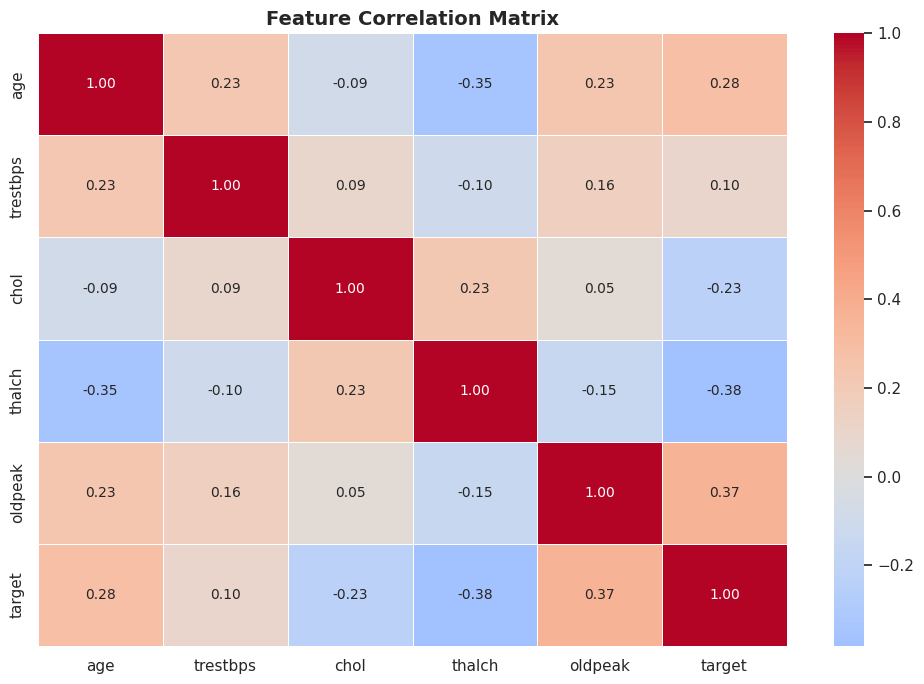


Correlations with target (sorted):
oldpeak     0.366138
age         0.282700
trestbps    0.101273
chol       -0.228976
thalch     -0.381864


In [24]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
# Shows linear relationships between numeric features and the target
# Helps identify which features are most predictive

numeric_cols = df.select_dtypes(include="number").drop(
    columns=["id", "num"], errors="ignore"
).columns.tolist()

print(f"Numeric columns in heatmap: {numeric_cols}")

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
    annot_kws={"size": 10},
)

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print the correlations with target specifically, sorted by strength
print("\nCorrelations with target (sorted):")
print(corr_matrix["target"].drop("target").sort_values(ascending=False).to_string())

### Boxplots: Key Features vs Target

Boxplots let us see how the distribution of each numeric feature differs
between patients with and without heart disease. A clear separation between
the two boxes suggests that feature is a strong predictor.

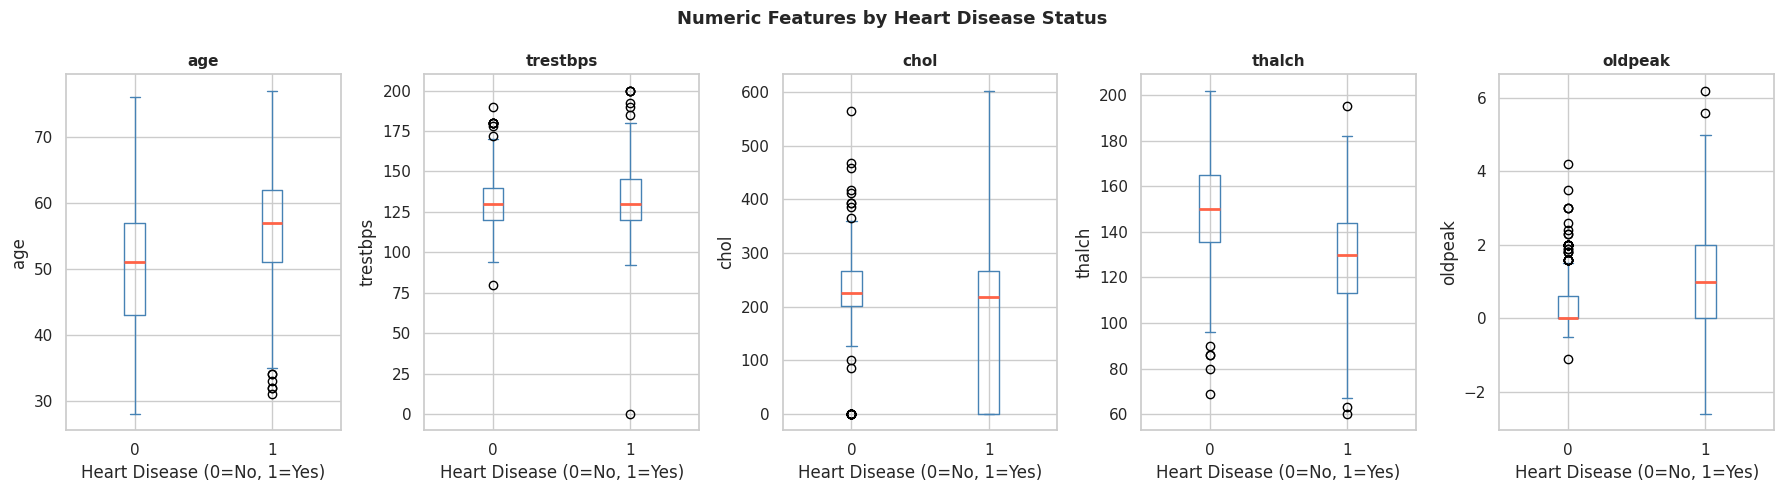

Median values by target group:
target        0      1
age        51.0   57.0
trestbps  130.0  130.0
chol      225.0  219.0
thalch    150.0  130.0
oldpeak     0.0    1.0


In [25]:
# ── Boxplots: numeric features vs target ─────────────────────────────────────
# Compare distributions between disease (1) and no disease (0) groups
# Clear separation between boxes = useful predictive feature

numeric_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 5))

for ax, col in zip(axes, numeric_features):
    df.boxplot(
        column=col,
        by="target",
        ax=ax,
        boxprops=dict(color="steelblue"),
        medianprops=dict(color="tomato", linewidth=2),
        whiskerprops=dict(color="steelblue"),
        capprops=dict(color="steelblue"),
    )
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("Heart Disease (0=No, 1=Yes)")
    ax.set_ylabel(col)

plt.suptitle("Numeric Features by Heart Disease Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print median values per group for reference
print("Median values by target group:")
print(df.groupby("target")[numeric_features].median().T.to_string())

### EDA Summary

Key observations from the exploratory analysis:

- **Age**: Disease patients are older on average (median 57 vs 51)
- **Max Heart Rate (`thalch`)**: Disease patients have a lower max heart rate (median 130 vs 150) — the heart struggles to reach high rates under stress
- **ST Depression (`oldpeak`)**: Disease patients show higher ST depression (median 1.0 vs 0.0) — a key clinical indicator of reduced blood flow
- **Blood Pressure (`trestbps`)**: Almost identical between groups (both median 130) — not a strong standalone predictor here
- **Cholesterol (`chol`)**: Slightly higher in the no-disease group (225 vs 219) — counterintuitive but consistent with the weak negative correlation (-0.23) we saw in the heatmap

In [27]:
X = df.drop(columns=["id", "num", "target", "dataset"])

In [28]:
# ── Identify column types for preprocessing ───────────────────────────────────
# The ColumnTransformer needs separate lists of numeric and categorical columns
# We exclude id, num, dataset, and target as these are not model features

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

print(f"Numeric columns   ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"\nTotal features: {len(num_cols) + len(cat_cols)}")

Numeric columns   (5): ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical columns (6): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

Total features: 11


## 3. Preprocessing

We build a `ColumnTransformer` that applies different transformations to different column types:

- **Numeric features** → `StandardScaler`: rescales to zero mean and unit variance so that features with large ranges (e.g. cholesterol) don't dominate the model
- **Categorical features** → `OneHotEncoder`: converts text categories into binary columns. `drop='first'` removes one column per feature to avoid multicollinearity

In [30]:
# ── Build the preprocessor ────────────────────────────────────────────────────
# ColumnTransformer applies the right transformation to each column type
# This gets embedded in the Pipeline so there is zero data leakage

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)

print("✅ Preprocessor built")
print(f"  Numeric  → StandardScaler  : {num_cols}")
print(f"  Categorical → OneHotEncoder: {cat_cols}")

✅ Preprocessor built
  Numeric  → StandardScaler  : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
  Categorical → OneHotEncoder: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']


In [31]:
# ── Train / test split ────────────────────────────────────────────────────────
# stratify=y ensures both splits have the same class ratio as the full dataset
# 80% training, 20% testing is a standard split for this dataset size

y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nClass balance in train:\n{y_train.value_counts().to_string()}")
print(f"\nClass balance in test:\n{y_test.value_counts().to_string()}")

Training set : 736 samples
Test set     : 184 samples

Class balance in train:
target
1    407
0    329

Class balance in test:
target
1    102
0     82


## 4. Model Training

We train two versions of Logistic Regression:

1. **Baseline** — default hyperparameters, quick sanity check
2. **Tuned** — `GridSearchCV` searches over regularisation strength (`C`) and penalty type (`l1` vs `l2`) using 5-fold cross-validation, optimising for F1 score

Both models are wrapped in a `Pipeline` with the preprocessor, ensuring the scaler and encoder are fitted only on training data and never see the test set.

In [32]:
# ── Baseline Logistic Regression ──────────────────────────────────────────────
# A simple starting point before any hyperparameter tuning
# liblinear solver works well for small-to-medium datasets like this one

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE)),
])

pipe_lr.fit(X_train, y_train)
print("✅ Baseline Logistic Regression trained")
print(f"   Solver    : liblinear")
print(f"   Max iter  : 1000")
print(f"   Features  : {X_train.shape[1]}")

✅ Baseline Logistic Regression trained
   Solver    : liblinear
   Max iter  : 1000
   Features  : 11


In [34]:
# ── Tuned Logistic Regression — GridSearchCV ──────────────────────────────────
# C controls regularisation strength — smaller C = stronger regularisation
# l1 penalty can zero out weak features (sparse); l2 shrinks all features evenly
# cv=5 means each combination is evaluated on 5 different train/val splits

param_grid = {
    "model__C":       [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
}

pipe_lr_cv = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE)),
])

grid_search = GridSearchCV(
    pipe_lr_cv, param_grid,
    cv=5, scoring="f1", n_jobs=-1, verbose=1,
)

grid_search.fit(X_train, y_train)
best_lr = grid_search.best_estimator_

print(f"\n✅ Grid search complete")
print(f"   Best parameters : {grid_search.best_params_}")
print(f"   Best CV F1 score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Grid search complete
   Best parameters : {'model__C': 0.1, 'model__penalty': 'l2'}
   Best CV F1 score: 0.8237


## 5. Model Evaluation

We evaluate both models on the **held-out test set** using four metrics:

| Metric | What it measures |
|---|---|
| **Accuracy** | % of all predictions that are correct |
| **Precision** | Of all predicted disease cases, how many are truly disease? |
| **Recall** | Of all actual disease cases, how many did we correctly catch? |
| **F1 Score** | Harmonic mean of Precision and Recall — balances both |

In a medical context **Recall is the most critical metric** — a False Negative (disease present but predicted absent) is far more costly than a False Positive.

In [35]:
# ── Evaluation helper function ────────────────────────────────────────────────
# Reusable function that prints metrics and stores them for later comparison
# We call this for both the baseline and tuned model

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall"   : recall_score(y_test, y_pred),
        "F1 Score" : f1_score(y_test, y_pred),
        "ROC-AUC"  : roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

    return metrics

print("✅ Evaluation function defined")

✅ Evaluation function defined


In [36]:
# ── Evaluate baseline and tuned models ───────────────────────────────────────
baseline_metrics = evaluate_model("Logistic Regression — Baseline", pipe_lr, X_test, y_test)
tuned_metrics    = evaluate_model("Logistic Regression — Tuned (GridSearchCV)", best_lr, X_test, y_test)


  Logistic Regression — Baseline
  Accuracy    : 0.8098
  Precision   : 0.8018
  Recall      : 0.8725
  F1 Score    : 0.8357
  ROC-AUC     : 0.9022

              precision    recall  f1-score   support

  No Disease       0.82      0.73      0.77        82
     Disease       0.80      0.87      0.84       102

    accuracy                           0.81       184
   macro avg       0.81      0.80      0.80       184
weighted avg       0.81      0.81      0.81       184


  Logistic Regression — Tuned (GridSearchCV)
  Accuracy    : 0.8261
  Precision   : 0.8182
  Recall      : 0.8824
  F1 Score    : 0.8491
  ROC-AUC     : 0.8902

              precision    recall  f1-score   support

  No Disease       0.84      0.76      0.79        82
     Disease       0.82      0.88      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.82       184



## 6. Confusion Matrix

The confusion matrix breaks down predictions into four categories:

|  | Predicted: No Disease | Predicted: Disease |
|---|---|---|
| **Actual: No Disease** | True Negative (TN) ✅ | False Positive (FP) ⚠️ |
| **Actual: Disease** | False Negative (FN) ❌ | True Positive (TP) ✅ |

**False Negatives are the most dangerous outcome** — the model missed a patient who actually has heart disease.


Baseline LR
  True Negatives  (correct no disease) : 60
  False Positives (wrongly flagged)     : 22
  False Negatives (missed disease)      : 13
  True Positives  (correct disease)     : 89

Tuned LR (GridSearchCV)
  True Negatives  (correct no disease) : 62
  False Positives (wrongly flagged)     : 20
  False Negatives (missed disease)      : 12
  True Positives  (correct disease)     : 90


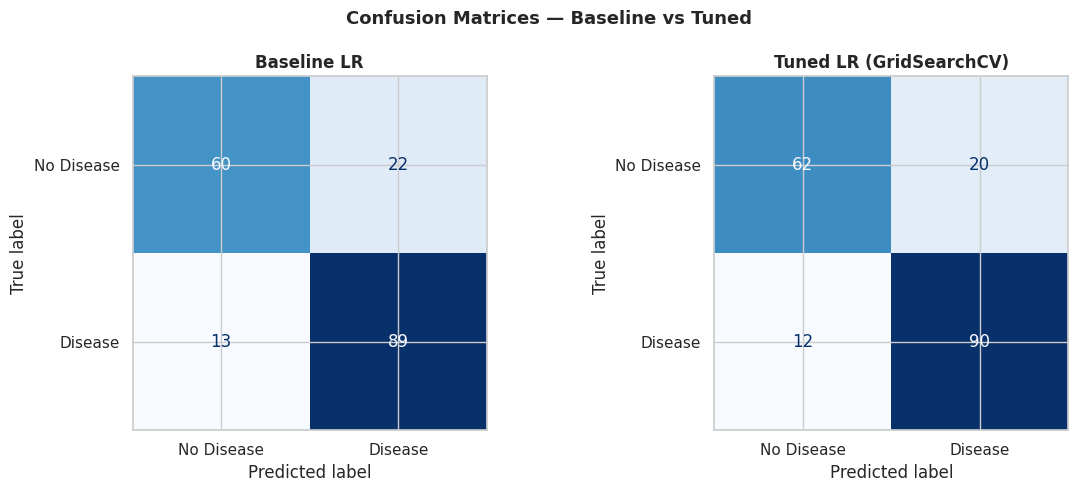

In [37]:
# ── Confusion matrices — baseline vs tuned ────────────────────────────────────
# Side by side comparison to see where each model makes mistakes
# Pay particular attention to False Negatives (bottom-left cell)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, [
    ("Baseline LR", pipe_lr),
    ("Tuned LR (GridSearchCV)", best_lr),
]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12, fontweight="bold")

    # Print the raw numbers for reference
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}")
    print(f"  True Negatives  (correct no disease) : {tn}")
    print(f"  False Positives (wrongly flagged)     : {fp}")
    print(f"  False Negatives (missed disease)      : {fn}")
    print(f"  True Positives  (correct disease)     : {tp}")

plt.suptitle("Confusion Matrices — Baseline vs Tuned", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. ROC Curve

The ROC curve plots **True Positive Rate (Recall)** against **False Positive Rate** at every possible classification threshold.

- A perfect model hugs the top-left corner
- The diagonal line represents a random classifier
- **AUC (Area Under Curve)** summarises the curve in one number — closer to 1.0 is better

Baseline LR — AUC: 0.9022
Tuned LR — AUC: 0.8902


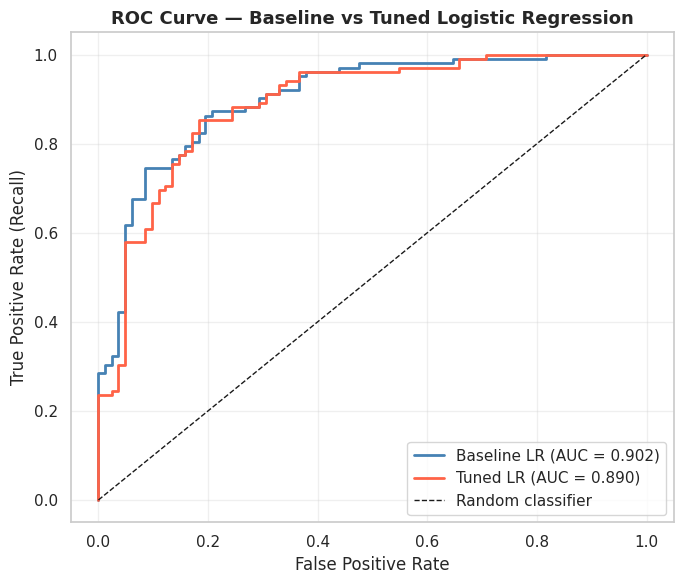

In [38]:
# ── ROC Curve — baseline vs tuned ────────────────────────────────────────────
# Compares both models across all possible classification thresholds
# AUC is threshold-independent — useful for overall model quality assessment

fig, ax = plt.subplots(figsize=(7, 6))

for name, model, color in [
    ("Baseline LR", pipe_lr,  "steelblue"),
    ("Tuned LR",    best_lr,  "tomato"),
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)
    print(f"{name} — AUC: {auc:.4f}")

# Random classifier baseline
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curve — Baseline vs Tuned Logistic Regression", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Model Comparison Summary

A side-by-side comparison of all metrics for both models.

=== Model Comparison ===
             Accuracy  Precision  Recall  F1 Score  ROC-AUC
Baseline LR    0.8098     0.8018  0.8725    0.8357   0.9022
Tuned LR       0.8261     0.8182  0.8824    0.8491   0.8902


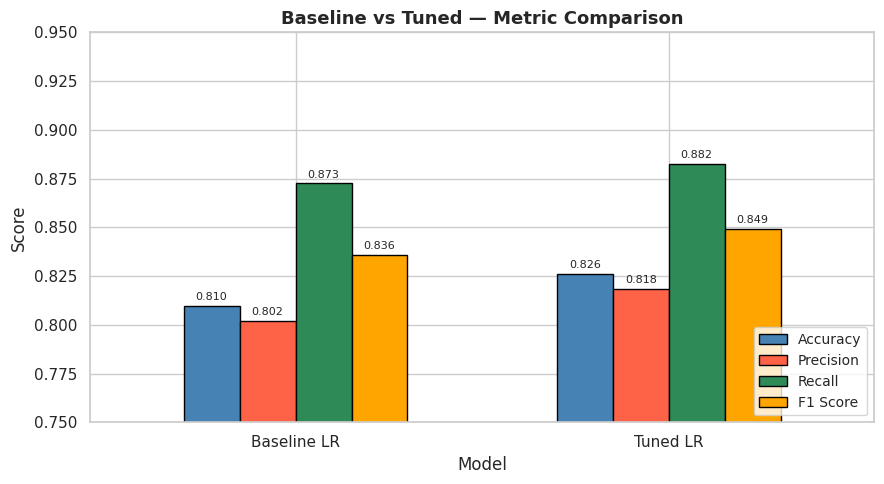

In [39]:
# ── Model comparison summary ──────────────────────────────────────────────────
# Consolidates all metrics into a single DataFrame for easy comparison

summary = pd.DataFrame({
    "Baseline LR": baseline_metrics,
    "Tuned LR"   : tuned_metrics,
}).T.round(4)

print("=== Model Comparison ===")
print(summary.to_string())

# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

summary[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", ax=ax,
    edgecolor="black",
    width=0.6,
    color=["steelblue", "tomato", "seagreen", "orange"],
)

ax.set_ylim(0.75, 0.95)
ax.set_title("Baseline vs Tuned — Metric Comparison", fontsize=13, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc="lower right", fontsize=10)

# Annotate bars with values
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=8,
    )

plt.tight_layout()
plt.show()

## 9. Feature Importance

Logistic Regression coefficients tell us how much each feature influences the prediction.
After scaling, the magnitude of each coefficient reflects its relative importance:

- **Positive coefficient** → pushes toward predicting Disease (1)
- **Negative coefficient** → pushes toward predicting No Disease (0)

We use the tuned model's coefficients since it is our best performer.

Total features after encoding: 15
Feature names: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping']

Top 10 most influential features:
           Feature  Coefficient
cp_atypical angina    -1.106199
        exang_True     0.808966
          sex_Male     0.731575
    cp_non-anginal    -0.660602
           oldpeak     0.537214
              chol    -0.371248
 cp_typical angina    -0.339467
            thalch    -0.330864
               age     0.321881
        slope_flat     0.265411


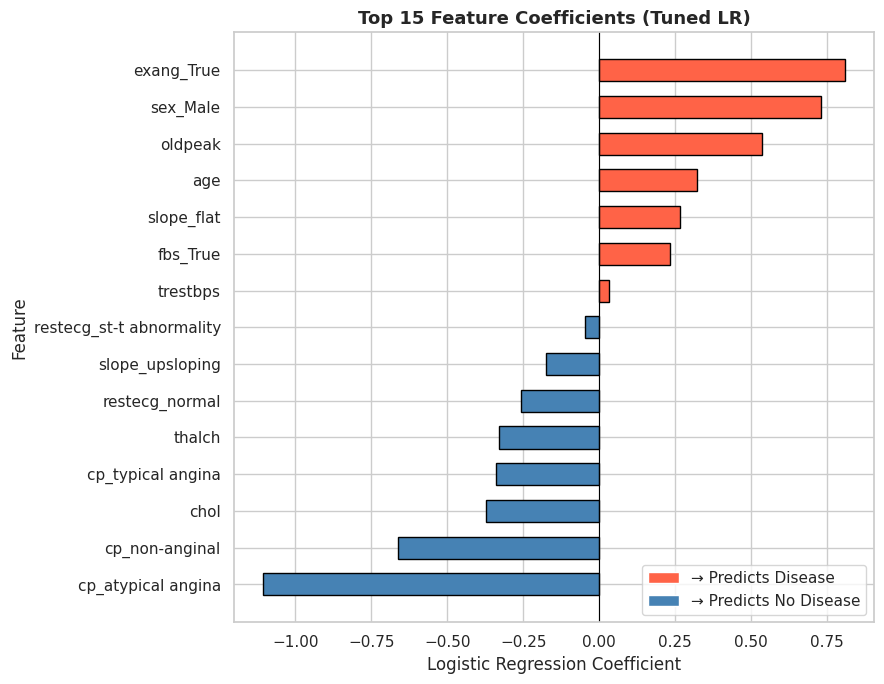

In [40]:
# ── Extract feature names after one-hot encoding ──────────────────────────────
# The OHE creates new binary columns for each category, so we need to retrieve
# the full list of feature names from the fitted preprocessor

ohe = best_lr.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

print(f"Total features after encoding: {len(all_feature_names)}")
print(f"Feature names: {all_feature_names}")

# ── Build coefficient DataFrame ───────────────────────────────────────────────
coefs = best_lr.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature"    : all_feature_names,
    "Coefficient": coefs,
})

# Sort by absolute value — magnitude matters more than direction here
coef_df = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index)

print("\nTop 10 most influential features:")
print(coef_df.head(10).to_string(index=False))

# ── Plot top 15 coefficients ──────────────────────────────────────────────────
top_n = coef_df.head(15).sort_values("Coefficient")
colors = ["tomato" if c > 0 else "steelblue" for c in top_n["Coefficient"]]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_n["Feature"], top_n["Coefficient"], color=colors, edgecolor="black", height=0.6)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 Feature Coefficients (Tuned LR)", fontsize=13, fontweight="bold")
ax.set_xlabel("Logistic Regression Coefficient")
ax.set_ylabel("Feature")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tomato",    label="→ Predicts Disease"),
    Patch(facecolor="steelblue", label="→ Predicts No Disease"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

## 10. Conclusions

### What We Did
1. **Loaded** the UCI Heart Disease dataset (920 patients, 16 columns)
2. **Explored** the data — identified missing values, class balance, feature distributions, and correlations
3. **Preprocessed** — dropped `ca` and `thal` (>50% missing), imputed remaining columns, scaled numeric features, one-hot encoded categoricals
4. **Trained** a Logistic Regression model — baseline and GridSearchCV-tuned (`C=0.1`, `l2` penalty)
5. **Evaluated** both models on a held-out test set of 184 patients

### Model Performance

| Metric | Baseline LR | Tuned LR |
|---|---|---|
| Accuracy | 0.8098 | 0.8261 |
| Precision | 0.8018 | 0.8182 |
| Recall | 0.8725 | 0.8824 |
| F1 Score | 0.8357 | 0.8491 |
| ROC-AUC | 0.9022 | 0.8902 |

The tuned model improved across all metrics except ROC-AUC, which dropped marginally (0.9022 → 0.8902). This suggests the default threshold (0.5) benefits from tuning, but the baseline model's overall ranking ability is slightly stronger.

### Key Clinical Findings

**Most influential features (from LR coefficients):**
- **`cp_atypical angina`** (coef: -1.11) — strongest predictor of *no disease*; atypical chest pain is reassuring
- **`exang_True`** (coef: +0.81) — exercise-induced angina strongly predicts disease
- **`sex_Male`** (coef: +0.73) — males in this dataset are more likely to have heart disease
- **`oldpeak`** (coef: +0.54) — higher ST depression under stress correlates with disease
- **`thalch`** (coef: -0.33) — lower max heart rate correlates with disease, consistent with our EDA (median 130 vs 150)
- **`chol`** (coef: -0.37) — slightly counterintuitive negative correlation, consistent with what we saw in the heatmap (-0.23)

### Confusion Matrix Summary
The tuned model made **12 False Negatives** (missed disease cases) vs 13 for the baseline — a small but meaningful improvement in a medical context where missed diagnoses carry real risk.

### Next Steps
- **Try SVM and XGBoost** — likely to outperform Logistic Regression on this dataset given the mix of numeric and categorical features
- **Threshold tuning** — lowering the classification threshold below 0.5 would further reduce False Negatives at the cost of more False Positives, which is often the right trade-off in medical screening
- **Address `ca` and `thal`**  — these were the strongest clinical predictors in the original dataset but had to be dropped due to missingness; a larger or cleaner dataset could unlock significant performance gains
- **SHAP values** — would give more reliable feature importance than raw coefficients, especially after one-hot encoding